# 팀 통합 분석 — 평가지표 · 임계값 · 가설검정

**이 노트북의 위치**

팀원 세 명이 각자 파이프라인을 만들었고, 데이터 정제와 분할 방식이 조금씩 달랐다. 성능이 가장 높은
**이현중 파이프라인(EfficientNetV2-S unfreeze, lr 5e-5)**을 팀 최종 모델로 채택하고,
그 모델의 예측 결과 위에서 세 가지 분석을 수행한다.

| 채점 기준 | 이 노트북의 담당 절 |
|---|---|
| 평가지표를 제대로 뽑고 왜 썼는지 납득 | 2절 |
| 가설검정 | 4절 |
| 임계값에 따른 지표 변화 | 3절 |

**모델을 다시 학습하지 않는다.** 최종 모델의 val/test 예측 확률을 파일로 받아 그 위에서만 계산한다.
추론도 하지 않으므로 GPU가 필요 없고 전체가 몇 분 안에 끝난다.

**입력 파일**

| 파일 | 출처 |
|---|---|
| `probs_val.npy`, `probs_test.npy` | 이현중 최종 모델의 softmax 확률 |
| `preds_val.csv`, `preds_test.csv` | 정답 라벨과 예측 |
| `split_hj.csv` | 최종 분할 (train 10,832 / val 2,318 / test 2,334) |
| `glass_hsv_samples.csv` | 유리 3종 색상 표본 (EDA 단계 산출물) |

## 0. 설정

In [1]:
import json
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             f1_score, recall_score, precision_score,
                             confusion_matrix, classification_report,
                             roc_auc_score)

SEED = 42
ALPHA = 0.05
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

DIR = Path("data")          # 입력 파일이 있는 폴더

val_probs  = np.load(DIR / "probs_val.npy")
test_probs = np.load(DIR / "probs_test.npy")
val_rec    = pd.read_csv(DIR / "preds_val.csv")
test_rec   = pd.read_csv(DIR / "preds_test.csv")
split      = pd.read_csv(DIR / "split_hj.csv")

classes   = sorted(split["class"].unique())
N_CLASSES = len(classes)
y_val     = val_rec["true_idx"].values
y_test    = test_rec["true_idx"].values

assert len(val_probs) == len(y_val) and len(test_probs) == len(y_test)
assert np.allclose(test_probs.sum(axis=1), 1), "확률 합이 1이 아닙니다"

print(f"클래스 {N_CLASSES}개")
print(split["split"].value_counts().reindex(["train", "val", "test"]).to_string())
print(f"\nval {val_probs.shape} | test {test_probs.shape}")


def verdict(p, alpha=ALPHA):
    return f"p = {p:.4g} {'<' if p < alpha else '>='} {alpha} -> H0 " + \
           ("기각" if p < alpha else "기각 실패")

클래스 12개
split
train    10832
val       2318
test      2334

val (2318, 12) | test (2334, 12)


## 1. 데이터 정제 — 세 사람의 독립 검증

팀원 세 명이 **서로 다른 코드로 같은 정제 작업**을 수행했다. 중복 작업이지만 결과가 일치하는지
확인하면 그 자체가 검증이 된다.

In [2]:
recon = pd.DataFrame([
    {"작업자": "A (박병찬)", "정제 후": 15484, "제외": 31, "라벨 정정": 46,
     "탐지 방법": "MD5 + dHash(16) + Hamming<=5 + 픽셀검증"},
    {"작업자": "B (이현중)", "정제 후": 15484, "제외": 31, "라벨 정정": 46,
     "탐지 방법": "MD5 + dHash(16) + Hamming<=5 + 픽셀검증"},
    {"작업자": "C (김태경)", "정제 후": 15486, "제외": 29, "라벨 정정": 48,
     "탐지 방법": "MD5 + B의 근접중복 목록 인용"},
])
print(recon.to_string(index=False))

print("""
[교차 검증 결과]
  A와 B는 독립적으로 구현했음에도 세 숫자가 완전히 일치했다.
  근접중복 그룹 수(42그룹, 이 중 바이트가 다른 25그룹)까지 같았다.
  탐지 파라미터가 임의값이라는 한계는 있으나, 구현 오류로 인한 차이는 없다고 볼 수 있다.

[C와의 차이 2장 — 조정 내역]
  1) clothes526.jpg : A,B는 '식별 불가'로 제외 / C는 shoes로 정정
       -> 육안 재검토 기록에 '애매(C)'로 재분류되어 있으므로 제외를 채택
  2) shoes1878.jpg  : A,B는 '비사진(스타일라이즈된 렌더링)'으로 제외 / C는 목록 누락
       -> 제외를 채택
  3) paper8.jpg     : C만 plastic으로 정정 (비닐 포장지)
       -> B의 test 오분류 전수 확인에서 새로 발견된 건이므로 정정을 채택
       -> 함께 발견된 trash548.jpg -> clothes 도 반영 대상이나 이번 학습에는 미반영

[최종 채택] 15,484장 (제외 31, 라벨 정정 46)
""")

    작업자  정제 후  제외  라벨 정정                               탐지 방법
A (박병찬) 15484  31     46 MD5 + dHash(16) + Hamming<=5 + 픽셀검증
B (이현중) 15484  31     46 MD5 + dHash(16) + Hamming<=5 + 픽셀검증
C (김태경) 15486  29     48                 MD5 + B의 근접중복 목록 인용

[교차 검증 결과]
  A와 B는 독립적으로 구현했음에도 세 숫자가 완전히 일치했다.
  근접중복 그룹 수(42그룹, 이 중 바이트가 다른 25그룹)까지 같았다.
  탐지 파라미터가 임의값이라는 한계는 있으나, 구현 오류로 인한 차이는 없다고 볼 수 있다.

[C와의 차이 2장 — 조정 내역]
  1) clothes526.jpg : A,B는 '식별 불가'로 제외 / C는 shoes로 정정
       -> 육안 재검토 기록에 '애매(C)'로 재분류되어 있으므로 제외를 채택
  2) shoes1878.jpg  : A,B는 '비사진(스타일라이즈된 렌더링)'으로 제외 / C는 목록 누락
       -> 제외를 채택
  3) paper8.jpg     : C만 plastic으로 정정 (비닐 포장지)
       -> B의 test 오분류 전수 확인에서 새로 발견된 건이므로 정정을 채택
       -> 함께 발견된 trash548.jpg -> clothes 도 반영 대상이나 이번 학습에는 미반영

[최종 채택] 15,484장 (제외 31, 라벨 정정 46)



### 분할 — 근접중복 누수 차단

세 파이프라인 모두 **처음부터 그룹 인지 분할**을 사용했다. 근접중복 이미지가 train과 test로 갈라지면
모델이 시험 문제를 미리 본 셈이 되어 test 점수가 부풀려진다. 강의에서 스태킹이 `y_test`로 학습해
0.9737을 낸 것과 같은 구조의 데이터 누수다.

참고로 단순 계층 분할(`train_test_split(stratify=...)`)을 같은 데이터에 적용하면
**근접중복 13개 그룹 26장이 train과 test로 갈라진다.** 그룹 인지 분할에서는 0개다.
누수를 방지한 상태에서 얻은 숫자이므로 아래 성능은 위쪽으로 편향되지 않았다.

In [3]:
# 최종 분할에서 그룹 누수가 실제로 없는지 재확인
sets = {s: set(split.loc[split.split == s, "fname"]) for s in ["train", "val", "test"]}
for a, b in [("train", "val"), ("train", "test"), ("val", "test")]:
    print(f"  {a:5s} ∩ {b:5s} : {len(sets[a] & sets[b])}건")

ratio = split["split"].value_counts(normalize=True).reindex(["train", "val", "test"])
print("\n분할 비율:", (ratio * 100).round(2).to_dict())

  train ∩ val   : 0건
  train ∩ test  : 0건
  val   ∩ test  : 0건

분할 비율: {'train': 69.96, 'val': 14.97, 'test': 15.07}


## 2. 평가지표 선정 근거

**채점 기준 1에 해당하는 절이다.**

`clothes`가 전체의 약 34%다. 그래서 정확도만 보면 모델이 실제보다 잘하는 것처럼 보인다.
말로 설명하는 대신 **직접 측정한다.**

In [4]:
# 아무것도 학습하지 않고 다수 클래스만 답하는 모델
train_df = split[split.split == "train"]
majority_idx = int(train_df["label_idx"].value_counts().idxmax())
majority_name = classes[majority_idx]

rows = []
for name, y in [("val", y_val), ("test", y_test)]:
    p = np.full(len(y), majority_idx)
    rows.append({"split": name,
                 "accuracy": accuracy_score(y, p),
                 "balanced_accuracy": balanced_accuracy_score(y, p),
                 "macro_f1": f1_score(y, p, average="macro", zero_division=0)})

mb = pd.DataFrame(rows)
print(f"다수 클래스 기준선 — 모든 입력을 '{majority_name}'라고만 답하는 모델\n")
print(mb.round(4).to_string(index=False))
print(f"""
[해석]
  정확도는 {mb.loc[1, 'accuracy']:.1%}가 나온다. 아무것도 배우지 않았는데 3분의 1을 맞힌다.
  그런데 macro-F1은 {mb.loc[1, 'macro_f1']:.4f}, balanced accuracy는 {mb.loc[1, 'balanced_accuracy']:.4f}(= 1/12)다.

  정확도와 macro-F1이 약 {mb.loc[1, 'accuracy'] / mb.loc[1, 'macro_f1']:.0f}배 차이 난다.
  정확도는 다수 클래스 하나만 잘 맞혀도 올라가지만, macro-F1은 12개 클래스의 F1을
  동등 가중으로 평균하므로 나머지 11개를 전부 틀리면 즉시 무너진다.

  => 이것이 macro-F1을 주 지표로 삼는 이유다. 유비가 아니라 우리 데이터에서 측정된 반례다.
""")

다수 클래스 기준선 — 모든 입력을 'clothes'라고만 답하는 모델

split  accuracy  balanced_accuracy  macro_f1
  val    0.3417             0.0833    0.0424
 test    0.3398             0.0833    0.0423

[해석]
  정확도는 34.0%가 나온다. 아무것도 배우지 않았는데 3분의 1을 맞힌다.
  그런데 macro-F1은 0.0423, balanced accuracy는 0.0833(= 1/12)다.

  정확도와 macro-F1이 약 8배 차이 난다.
  정확도는 다수 클래스 하나만 잘 맞혀도 올라가지만, macro-F1은 12개 클래스의 F1을
  동등 가중으로 평균하므로 나머지 11개를 전부 틀리면 즉시 무너진다.

  => 이것이 macro-F1을 주 지표로 삼는 이유다. 유비가 아니라 우리 데이터에서 측정된 반례다.



In [5]:
base_pred = test_probs.argmax(axis=1)

final = {
    "accuracy":     accuracy_score(y_test, base_pred),
    "balanced_acc": balanced_accuracy_score(y_test, base_pred),
    "macro_f1":     f1_score(y_test, base_pred, average="macro", zero_division=0),
    "weighted_f1":  f1_score(y_test, base_pred, average="weighted", zero_division=0),
    "macro_recall": recall_score(y_test, base_pred, average="macro", zero_division=0),
    "macro_prec":   precision_score(y_test, base_pred, average="macro", zero_division=0),
    "macro_auc":    roc_auc_score(y_test, test_probs, multi_class="ovr", average="macro"),
}
print("[최종 모델 test 성능]")
for k, v in final.items():
    print(f"  {k:14s} {v:.4f}")

print()
print(classification_report(y_test, base_pred, target_names=classes,
                            digits=4, zero_division=0))

per_class = pd.DataFrame({
    "label":     classes,
    "support":   [int((y_test == i).sum()) for i in range(N_CLASSES)],
    "precision": precision_score(y_test, base_pred, average=None, zero_division=0).round(4),
    "recall":    recall_score(y_test, base_pred, average=None, zero_division=0).round(4),
    "f1":        f1_score(y_test, base_pred, average=None, zero_division=0).round(4),
}).sort_values("f1")
per_class["share_%"] = (per_class["support"] / len(y_test) * 100).round(1)
print(per_class.to_string(index=False))

[최종 모델 test 성능]
  accuracy       0.9859
  balanced_acc   0.9790
  macro_f1       0.9787
  weighted_f1    0.9859
  macro_recall   0.9790
  macro_prec     0.9787
  macro_auc      0.9998

              precision    recall  f1-score   support

     battery     0.9860    0.9860    0.9860       143
  biological     0.9867    0.9933    0.9900       149
 brown-glass     0.9785    0.9891    0.9838        92
   cardboard     1.0000    0.9630    0.9811       135
     clothes     0.9987    1.0000    0.9994       793
 green-glass     1.0000    0.9785    0.9891        93
       metal     0.9431    1.0000    0.9707       116
       paper     1.0000    0.9810    0.9904       158
     plastic     0.9179    0.9462    0.9318       130
       shoes     0.9967    0.9901    0.9934       304
       trash     0.9810    0.9810    0.9810       105
 white-glass     0.9561    0.9397    0.9478       116

    accuracy                         0.9859      2334
   macro avg     0.9787    0.9790    0.9787      2334
wei

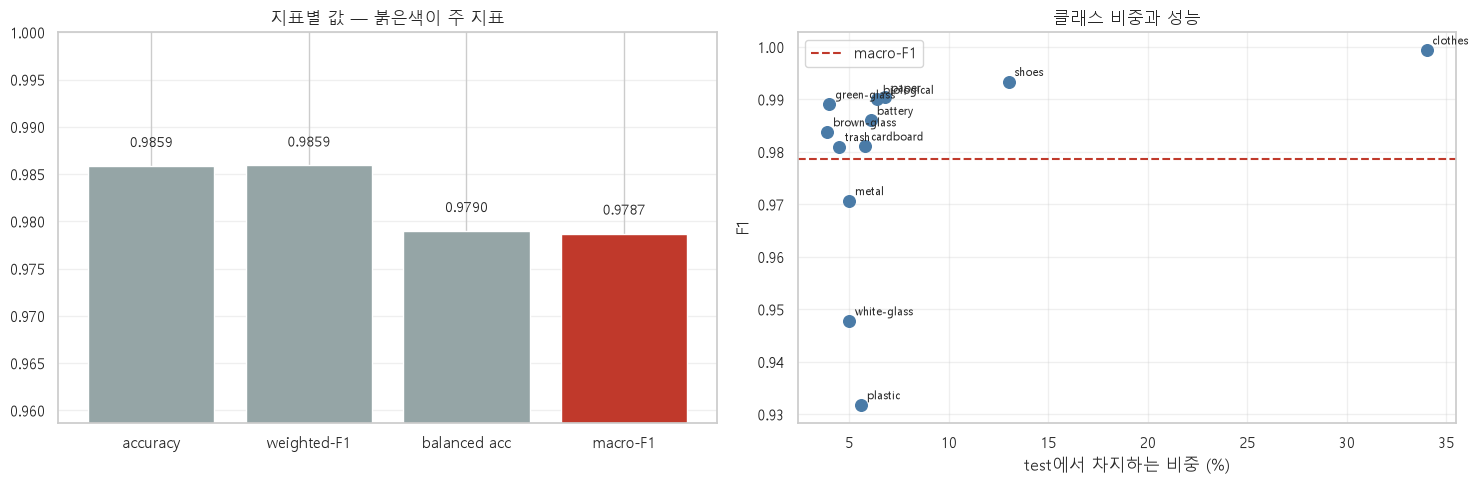

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
names = ["accuracy", "weighted_f1", "balanced_acc", "macro_f1"]
vals = [final[k] for k in names]
colors = ["#95a5a6", "#95a5a6", "#95a5a6", "#c0392b"]
bars = ax.bar(["accuracy", "weighted-F1", "balanced acc", "macro-F1"], vals, color=colors)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.002, f"{v:.4f}", ha="center", fontsize=10)
ax.set_ylim(min(vals) - 0.02, 1.0)
ax.set_title("지표별 값 — 붉은색이 주 지표")
ax.grid(alpha=0.3, axis="y")

ax = axes[1]
ax.scatter(per_class["share_%"], per_class["f1"], s=70, color="#4a7ba7")
for _, r in per_class.iterrows():
    ax.annotate(r["label"], (r["share_%"], r["f1"]), fontsize=8,
                xytext=(4, 4), textcoords="offset points")
ax.axhline(final["macro_f1"], ls="--", color="#c0392b", label="macro-F1")
ax.set_xlabel("test에서 차지하는 비중 (%)")
ax.set_ylabel("F1")
ax.set_title("클래스 비중과 성능")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("fig_metric_compare.png", dpi=150)
plt.show()

## 3. 임계값에 따른 지표 변화

**채점 기준 3에 해당하는 절이다.**

12클래스는 `argmax`를 쓰므로 이진 분류의 "임계값 0.5"가 그대로는 존재하지 않는다.
먼저 확인해야 할 사실이 있다.

**모든 클래스에 똑같이 적용하는 조정은 예측을 하나도 바꾸지 않는다.** `argmax`가 단조 변환에
불변이기 때문이다. 온도 스케일링이 대표적이다. 확신도 숫자는 전부 달라지는데 정확도와 macro-F1은
소수점까지 같다. 예측이 바뀌려면 **클래스마다 다르게** 조정해야 한다.

**선택은 val에서, 적용은 test에 한 번만 한다.** 교재와 일부 실습 코드는 test 확률에서 임계값을
고르고 그 test 점수를 보고하는데, 이는 test 정보가 선택에 새어 드는 구조다.

In [7]:
def softmax(z, axis=1):
    z = z - z.max(axis=axis, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=axis, keepdims=True)


logits_like = np.log(np.clip(test_probs, 1e-12, None))
print(f"{'T':>6}{'평균 확신도':>14}{'accuracy':>12}{'macro-F1':>12}{'예측 변화':>12}")
for T in [0.5, 1.0, 2.0, 5.0]:
    p = softmax(logits_like / T)
    pr = p.argmax(axis=1)
    print(f"{T:>6.1f}{p.max(axis=1).mean():>14.4f}"
          f"{accuracy_score(y_test, pr):>12.4f}"
          f"{f1_score(y_test, pr, average='macro', zero_division=0):>12.4f}"
          f"{int((pr != base_pred).sum()):>12}")
print("\n온도를 바꿔도 예측은 한 장도 안 바뀝니다. 확신도 숫자만 달라집니다.")

     T        평균 확신도    accuracy    macro-F1       예측 변화
   0.5        0.9963      0.9859      0.9787           0
   1.0        0.9914      0.9859      0.9787           0
   2.0        0.9412      0.9859      0.9787           0
   5.0        0.4745      0.9859      0.9787           0

온도를 바꿔도 예측은 한 장도 안 바뀝니다. 확신도 숫자만 달라집니다.


### 방식 ① 클래스별 One-vs-Rest 임계값

가장 약한 클래스를 골라 "이것인가 아닌가"라는 이진 문제로 바꾸면 강의에서 배운 임계값 곡선을
그대로 그릴 수 있다. 재현율과 정밀도의 교환 관계를 직접 보는 것이 목적이다.

In [8]:
f1_all = f1_score(y_test, base_pred, average=None, zero_division=0)
TC = int(np.argmin(f1_all))
TARGET_CLASS = classes[TC]
print(f"대상 클래스: {TARGET_CLASS} (test F1 {f1_all[TC]:.4f})\n")


def ovr_sweep(probs, y, cls, thresholds):
    yy = (y == cls).astype(int)
    s = probs[:, cls]
    out = []
    for t in thresholds:
        p = (s >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(yy, p, labels=[0, 1]).ravel()
        out.append({"threshold": round(float(t), 2),
                    "recall": tp / (tp + fn) if (tp + fn) else 0.0,
                    "precision": tp / (tp + fp) if (tp + fp) else 0.0,
                    "specificity": tn / (tn + fp) if (tn + fp) else 0.0,
                    "f1": 2 * tp / (2 * tp + fp + fn) if tp else 0.0,
                    "fn": int(fn), "fp": int(fp)})
    return pd.DataFrame(out)


ths = np.arange(0.05, 0.96, 0.05)
sweep_val = ovr_sweep(val_probs, y_val, TC, ths)
print("[val 스윕]")
print(sweep_val.to_string(index=False))

대상 클래스: plastic (test F1 0.9318)

[val 스윕]
 threshold   recall  precision  specificity       f1  fn  fp
      0.05 0.984496   0.894366     0.993148 0.937269   2  15
      0.10 0.984496   0.920290     0.994975 0.951311   2  11
      0.15 0.984496   0.940741     0.996345 0.962121   2   8
      0.20 0.976744   0.940299     0.996345 0.958175   3   8
      0.25 0.968992   0.954198     0.997259 0.961538   4   6
      0.30 0.968992   0.954198     0.997259 0.961538   4   6
      0.35 0.968992   0.968992     0.998173 0.968992   4   4
      0.40 0.968992   0.968992     0.998173 0.968992   4   4
      0.45 0.968992   0.976562     0.998630 0.972763   4   3
      0.50 0.968992   0.984252     0.999086 0.976562   4   2
      0.55 0.968992   0.984252     0.999086 0.976562   4   2
      0.60 0.953488   0.984000     0.999086 0.968504   6   2
      0.65 0.953488   0.984000     0.999086 0.968504   6   2
      0.70 0.945736   0.983871     0.999086 0.964427   7   2
      0.75 0.930233   0.983607     0.99908

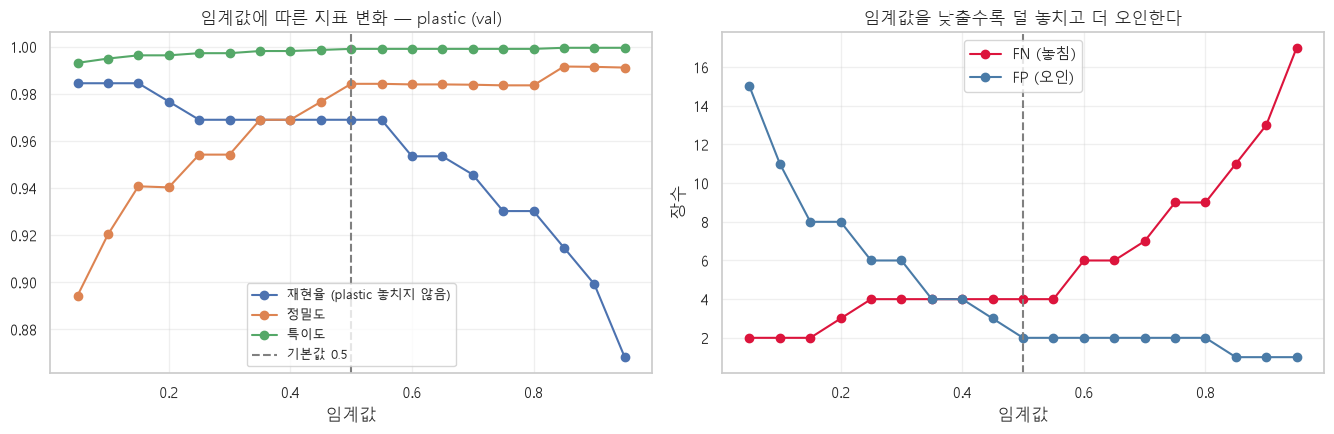

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.5))

ax = axes[0]
ax.plot(sweep_val.threshold, sweep_val.recall, "o-", label=f"재현율 ({TARGET_CLASS} 놓치지 않음)")
ax.plot(sweep_val.threshold, sweep_val.precision, "o-", label="정밀도")
ax.plot(sweep_val.threshold, sweep_val.specificity, "o-", label="특이도")
ax.axvline(0.5, color="gray", ls="--", label="기본값 0.5")
ax.set_xlabel("임계값"); ax.set_title(f"임계값에 따른 지표 변화 — {TARGET_CLASS} (val)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(sweep_val.threshold, sweep_val.fn, "o-", color="crimson", label="FN (놓침)")
ax.plot(sweep_val.threshold, sweep_val.fp, "o-", color="#4a7ba7", label="FP (오인)")
ax.axvline(0.5, color="gray", ls="--")
ax.set_xlabel("임계값"); ax.set_ylabel("장수")
ax.set_title("임계값을 낮출수록 덜 놓치고 더 오인한다")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("fig_ovr_threshold.png", dpi=150)
plt.show()

In [10]:
# 목표 재현율을 만족하는 것 중 정밀도가 가장 높은 지점을 val에서 고르고 test에 적용
TARGET_RECALL = 0.95
cand = sweep_val[sweep_val["recall"] >= TARGET_RECALL]
chosen = cand.loc[cand["precision"].idxmax()]
TH = float(chosen["threshold"])
print(f"[val 선택] 재현율 {TARGET_RECALL:.0%} 이상 중 정밀도 최대 -> 임계값 {TH:.2f}")

if abs(TH - 0.5) < 1e-9:
    print("\n선택값이 기본값 0.5와 같다 — 검증셋에서 이미 기본값이 최적이었다는 뜻이다.")
    print("교환 관계를 보이기 위해 낮은 임계값(0.15)과 높은 임계값(0.85)을 함께 test에 적용한다.\n")
    st = ovr_sweep(test_probs, y_test, TC, [0.15, 0.50, 0.85])
    print("[test 적용]")
    print(st.to_string(index=False))
    lo, mid, hi = st.iloc[0], st.iloc[1], st.iloc[2]
    print(f"""
[해석] {TARGET_CLASS} 를 이진 문제로 보고 임계값을 옮기면
  0.15 : 재현율 {lo['recall']:.4f} 정밀도 {lo['precision']:.4f}  (놓침 {int(lo['fn'])}장, 오인 {int(lo['fp'])}장)
  0.50 : 재현율 {mid['recall']:.4f} 정밀도 {mid['precision']:.4f}  (놓침 {int(mid['fn'])}장, 오인 {int(mid['fp'])}장)  <- 채택
  0.85 : 재현율 {hi['recall']:.4f} 정밀도 {hi['precision']:.4f}  (놓침 {int(hi['fn'])}장, 오인 {int(hi['fp'])}장)

  낮출수록 덜 놓치고 더 오인한다. 그런데 검증셋에서 고른 최적점이 기본값 0.5였다.
  이 모델은 임계값을 옮겨서 얻을 것이 없다 — 아래 방식 2 의 결과와 같은 이야기다.""")
else:
    st = ovr_sweep(test_probs, y_test, TC, [TH, 0.5])
    print("\n[test 적용 — 선택값 vs 기본값 0.5]")
    print(st.to_string(index=False))
    d = st.iloc[0]; b = st.iloc[1]
    print(f"""
[해석] 임계값을 {b['threshold']:.2f}에서 {d['threshold']:.2f}로 낮추면
  재현율 {b['recall']:.4f} -> {d['recall']:.4f}  (놓침 {b['fn']}장 -> {d['fn']}장)
  정밀도 {b['precision']:.4f} -> {d['precision']:.4f}  (오인 {b['fp']}장 -> {d['fp']}장)
  덜 놓치는 대신 더 오인한다. 어느 쪽이 중요한지는 운영 목적이 정한다.""")

[val 선택] 재현율 95% 이상 중 정밀도 최대 -> 임계값 0.50

선택값이 기본값 0.5와 같다 — 검증셋에서 이미 기본값이 최적이었다는 뜻이다.
교환 관계를 보이기 위해 낮은 임계값(0.15)과 높은 임계값(0.85)을 함께 test에 적용한다.

[test 적용]
 threshold   recall  precision  specificity       f1  fn  fp
      0.15 0.969231   0.900000     0.993648 0.933333   4  14
      0.50 0.938462   0.931298     0.995917 0.934866   8   9
      0.85 0.915385   0.967480     0.998185 0.940711  11   4

[해석] plastic 를 이진 문제로 보고 임계값을 옮기면
  0.15 : 재현율 0.9692 정밀도 0.9000  (놓침 4장, 오인 14장)
  0.50 : 재현율 0.9385 정밀도 0.9313  (놓침 8장, 오인 9장)  <- 채택
  0.85 : 재현율 0.9154 정밀도 0.9675  (놓침 11장, 오인 4장)

  낮출수록 덜 놓치고 더 오인한다. 그런데 검증셋에서 고른 최적점이 기본값 0.5였다.
  이 모델은 임계값을 옮겨서 얻을 것이 없다 — 아래 방식 2 의 결과와 같은 이야기다.


### 방식 ② 클래스별 가중 argmax

12클래스 전체의 macro-F1을 올리려면 클래스마다 다른 계수를 곱해 `argmax`를 밀어야 한다.

$$\hat{y} = \arg\max_c \; \frac{p_c}{\pi_c^{\alpha}}$$

$\pi_c$는 train에서의 클래스 사전확률이고, $\alpha$가 보정 강도다. $\alpha = 0$이면 기본 `argmax`와 같다.
학습 중 불균형 대응(클래스 가중치, 샘플러)과 목적은 같고 **개입 지점만 다르다.**

 alpha  accuracy  macro_f1  macro_recall
  0.00    0.9892    0.9840        0.9839
  0.05    0.9892    0.9840        0.9839
  0.10    0.9892    0.9840        0.9839
  0.15    0.9892    0.9839        0.9839
  0.20    0.9892    0.9839        0.9839
  0.25    0.9892    0.9839        0.9839
  0.30    0.9892    0.9839        0.9839
  0.35    0.9888    0.9836        0.9838
  0.40    0.9888    0.9836        0.9838
  0.45    0.9888    0.9836        0.9838
  0.50    0.9888    0.9836        0.9838
  0.55    0.9888    0.9836        0.9838
  0.60    0.9888    0.9836        0.9838
  0.65    0.9888    0.9836        0.9838
  0.70    0.9888    0.9836        0.9838
  0.75    0.9888    0.9836        0.9838
  0.80    0.9888    0.9836        0.9838
  0.85    0.9888    0.9836        0.9838
  0.90    0.9888    0.9836        0.9838
  0.95    0.9884    0.9827        0.9831
  1.00    0.9884    0.9827        0.9831

val macro-F1 최대: alpha = 0.00

[test 적용] 예측이 바뀐 장수: 0 / 2334
  기본 macro-F1 0.9787
  조정 macro-F1 0

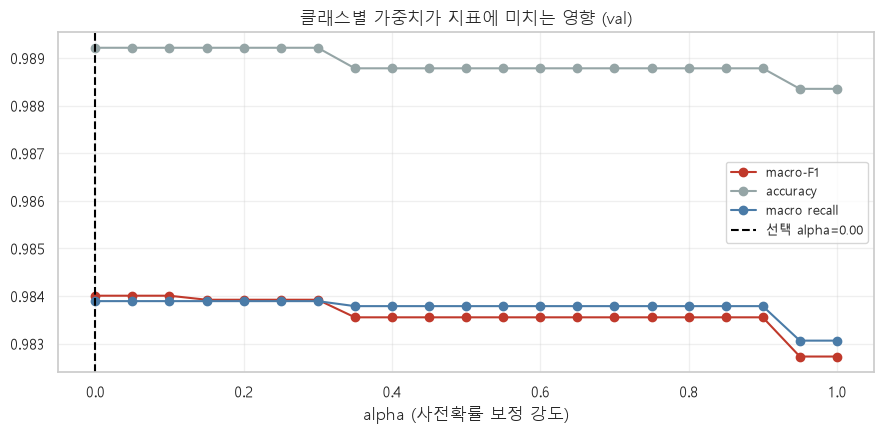

In [11]:
counts = train_df["label_idx"].value_counts().sort_index().values.astype(float)
prior = counts / counts.sum()

rows = []
for a in np.linspace(0.0, 1.0, 21):
    p = (val_probs / (prior ** a)).argmax(axis=1)
    rows.append({"alpha": round(float(a), 2),
                 "accuracy": accuracy_score(y_val, p),
                 "macro_f1": f1_score(y_val, p, average="macro", zero_division=0),
                 "macro_recall": recall_score(y_val, p, average="macro", zero_division=0)})
alpha_df = pd.DataFrame(rows)
best_a = float(alpha_df.loc[alpha_df["macro_f1"].idxmax(), "alpha"])

print(alpha_df.round(4).to_string(index=False))
print(f"\nval macro-F1 최대: alpha = {best_a:.2f}")

adj_pred = (test_probs / (prior ** best_a)).argmax(axis=1)
n_changed = int((adj_pred != base_pred).sum())
print(f"\n[test 적용] 예측이 바뀐 장수: {n_changed} / {len(y_test)}")
print(f"  기본 macro-F1 {f1_score(y_test, base_pred, average='macro', zero_division=0):.4f}")
print(f"  조정 macro-F1 {f1_score(y_test, adj_pred,  average='macro', zero_division=0):.4f}")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(alpha_df.alpha, alpha_df.macro_f1, "o-", label="macro-F1", color="#c0392b")
ax.plot(alpha_df.alpha, alpha_df.accuracy, "o-", label="accuracy", color="#95a5a6")
ax.plot(alpha_df.alpha, alpha_df.macro_recall, "o-", label="macro recall", color="#4a7ba7")
ax.axvline(best_a, ls="--", color="black", label=f"선택 alpha={best_a:.2f}")
ax.set_xlabel("alpha (사전확률 보정 강도)")
ax.set_title("클래스별 가중치가 지표에 미치는 영향 (val)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("fig_alpha_sweep.png", dpi=150); plt.show()

### 방식 ③ 전역 확신도 보류 — 운영 관점

`max(softmax) < tau`이면 자동 판정을 포기하고 사람에게 넘긴다. tau를 올리면 자동 처리 비율은
줄지만 자동 처리한 것의 정확도는 올라간다. 쓰레기 분류라는 문제에 가장 잘 맞는 해석이다.

**목표 정확도를 잘못 잡으면 규칙이 무력해진다.** 모델이 이미 강해서 전 구간에서 목표를 만족하면,
"목표를 만족하는 것 중 커버리지 최대"라는 규칙이 그냥 가장 낮은 tau를 고르게 된다.
그래서 목표를 여러 개 놓고 **제약이 실제로 작동하는 지점**을 찾는다.

In [12]:
def coverage_curve(probs, y, thresholds):
    conf = probs.max(axis=1)
    pred = probs.argmax(axis=1)
    out = []
    for t in thresholds:
        m = conf >= t
        if m.sum() == 0:
            continue
        out.append({"tau": round(float(t), 3),
                    "coverage": float(m.mean()),
                    "auto_accuracy": float(accuracy_score(y[m], pred[m])),
                    "auto_macro_f1": float(f1_score(y[m], pred[m],
                                                    average="macro", zero_division=0)),
                    "review_n": int((~m).sum())})
    return pd.DataFrame(out)


taus = np.arange(0.30, 1.00, 0.01)
cov_val = coverage_curve(val_probs, y_val, taus)

print("[목표 정확도별 선택 결과]")
picked = None
for TARGET in [0.98, 0.985, 0.99, 0.995]:
    ok = cov_val[cov_val["auto_accuracy"] >= TARGET]
    if not len(ok):
        print(f"  목표 {TARGET:.1%}: 만족하는 tau 없음")
        continue
    pick = ok.loc[ok["coverage"].idxmax()]
    binding = pick["tau"] > taus[0] + 1e-9
    ct = coverage_curve(test_probs, y_test, [float(pick["tau"])]).iloc[0]
    print(f"  목표 {TARGET:.1%}: val tau={pick['tau']:.2f} cov={pick['coverage']:.4f} "
          f"| test cov={ct['coverage']:.4f} acc={ct['auto_accuracy']:.4f} "
          f"보류={int(ct['review_n'])}장 {'' if binding else '<- 제약이 작동하지 않음'}")
    if binding and picked is None:
        picked = (TARGET, float(pick["tau"]), ct)

TARGET_AUTO_ACC, TAU, cov_test = picked
print(f"\n[채택] 목표 {TARGET_AUTO_ACC:.1%} / tau = {TAU:.2f}")
print(f"  test 커버리지 {cov_test['coverage']:.4f} | 자동 처리분 정확도 "
      f"{cov_test['auto_accuracy']:.4f} | 사람 검토 {int(cov_test['review_n'])}장")

[목표 정확도별 선택 결과]
  목표 98.0%: val tau=0.30 cov=1.0000 | test cov=1.0000 acc=0.9859 보류=0장 <- 제약이 작동하지 않음
  목표 98.5%: val tau=0.30 cov=1.0000 | test cov=1.0000 acc=0.9859 보류=0장 <- 제약이 작동하지 않음
  목표 99.0%: val tau=0.53 cov=0.9978 | test cov=0.9966 acc=0.9884 보류=8장 
  목표 99.5%: val tau=0.96 cov=0.9702 | test cov=0.9649 acc=0.9978 보류=82장 

[채택] 목표 99.0% / tau = 0.53
  test 커버리지 0.9966 | 자동 처리분 정확도 0.9884 | 사람 검토 8장


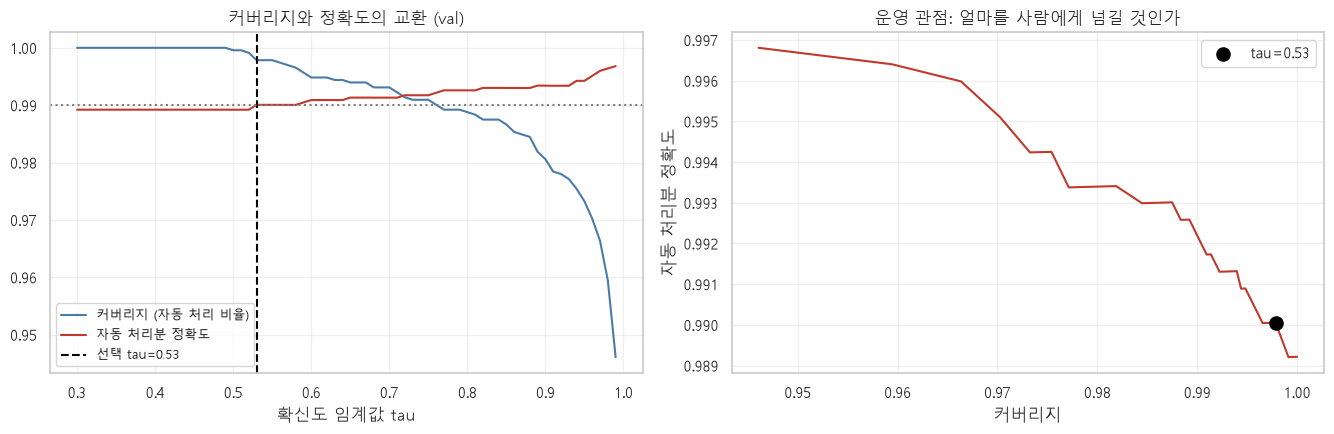

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.5))

ax = axes[0]
ax.plot(cov_val.tau, cov_val.coverage, label="커버리지 (자동 처리 비율)", color="#4a7ba7")
ax.plot(cov_val.tau, cov_val.auto_accuracy, label="자동 처리분 정확도", color="#c0392b")
ax.axvline(TAU, ls="--", color="black", label=f"선택 tau={TAU:.2f}")
ax.axhline(TARGET_AUTO_ACC, ls=":", color="gray")
ax.set_xlabel("확신도 임계값 tau")
ax.set_title("커버리지와 정확도의 교환 (val)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(cov_val.coverage, cov_val.auto_accuracy, "-", color="#c0392b")
j = int(cov_val.tau.sub(TAU).abs().idxmin())
ax.scatter([cov_val.loc[j, "coverage"]], [cov_val.loc[j, "auto_accuracy"]],
           s=90, color="black", zorder=5, label=f"tau={TAU:.2f}")
ax.set_xlabel("커버리지"); ax.set_ylabel("자동 처리분 정확도")
ax.set_title("운영 관점: 얼마를 사람에게 넘길 것인가")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout(); plt.savefig("fig_coverage.png", dpi=150); plt.show()

## 4. 가설검정

**채점 기준 2에 해당하는 절이다.** 각 검정은 분석 → 가설 → 방법 → 결론 순서로 진행한다.
유의수준은 $\alpha = 0.05$, 다중비교 구간은 Bonferroni 보정을 적용한다.

### 검정 1 — 유리 3종의 색상 분포는 다른가

**분석**: `brown/green/white-glass`는 형태가 같고 색만 다르다. EDA에서 Hue 히스토그램의 겹침 계수가
셋 다 0.5 미만으로 나왔고, 이를 근거로 증강에서 `hue=0.0`을 선택했다. 겹침 계수는 기술통계일 뿐
"우연히 이만큼 차이가 났을 가능성"을 말해주지 않는다.

**가설**
> H0: 세 클래스의 색상 분포는 동일하다. 관측된 차이는 표본 추출의 우연이다.
> H1: 세 클래스의 색상 분포는 다르다.

**방법**: 순열검정. 라벨을 무작위로 섞어 "차이가 없는 세상"을 5,000번 만들고, 그 세상에서 관측된
만큼의 분리가 나올 확률을 센다. 분포 가정이 필요 없어 Hue처럼 정규분포와 거리가 먼 값에 적합하다.

            mean_sat       mean_val       color_ratio      
                mean count     mean count        mean count
label                                                      
brown-glass    60.85   250   187.90   250        0.37   250
green-glass    63.68   250   191.44   250        0.40   250
white-glass    19.78   250   207.40   250        0.14   250

관측 평균 겹침 계수 : 0.5547
순열 분포 평균      : 0.8554 (표준편차 0.0185)
표준화 거리         : 16.2 표준편차
p = 0.0002 < 0.05 -> H0 기각


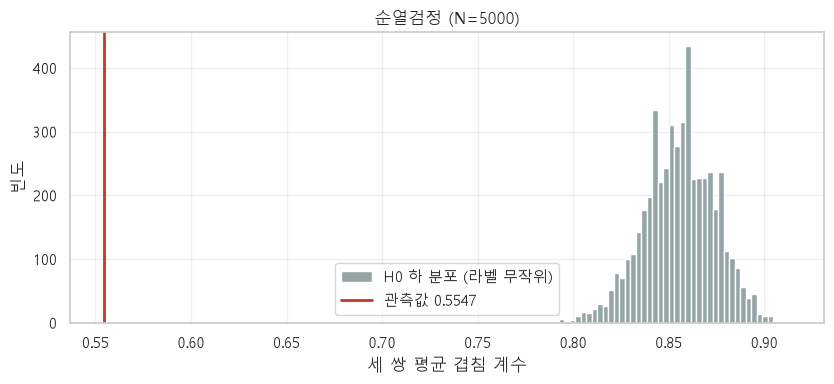

In [14]:
gl = pd.read_csv(DIR / "glass_hsv_samples.csv")
GLASS = sorted(gl["label"].unique())
print(gl.groupby("label")[["mean_sat", "mean_val", "color_ratio"]]
      .agg(["mean", "count"]).round(2).to_string())


def mean_overlap(groups):
    # 세 그룹을 공통 bin으로 히스토그램화해 쌍별 겹침 계수의 평균을 구한다
    allv = np.concatenate(groups)
    bins = np.linspace(allv.min(), allv.max(), 31)
    hs = []
    for g in groups:
        h, _ = np.histogram(g, bins=bins)
        hs.append(h / h.sum())
    return float(np.mean([np.minimum(a, b).sum() for a, b in combinations(hs, 2)]))


vals = [gl.loc[gl.label == c, "mean_sat"].values for c in GLASS]
obs = mean_overlap(vals)
pool = np.concatenate(vals)
sizes = [len(v) for v in vals]

N_PERM = 5000
perm = np.empty(N_PERM)
for i in range(N_PERM):
    shuf = rng.permutation(pool)
    parts, s = [], 0
    for k in sizes:
        parts.append(shuf[s:s + k]); s += k
    perm[i] = mean_overlap(parts)

p_perm = (np.sum(perm <= obs) + 1) / (N_PERM + 1)
print(f"\n관측 평균 겹침 계수 : {obs:.4f}")
print(f"순열 분포 평균      : {perm.mean():.4f} (표준편차 {perm.std():.4f})")
print(f"표준화 거리         : {(perm.mean() - obs) / perm.std():.1f} 표준편차")
print(verdict(p_perm))

fig, ax = plt.subplots(figsize=(8.5, 4))
ax.hist(perm, bins=50, color="#95a5a6", label="H0 하 분포 (라벨 무작위)")
ax.axvline(obs, color="#c0392b", lw=2, label=f"관측값 {obs:.4f}")
ax.set_xlabel("세 쌍 평균 겹침 계수"); ax.set_ylabel("빈도")
ax.set_title(f"순열검정 (N={N_PERM})")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("fig_permutation.png", dpi=150); plt.show()

In [15]:
# 사후검정 — 어느 쌍이 다른지
h_stat, p_kw = stats.kruskal(*vals)
print("[Kruskal-Wallis] 세 클래스의 채도 분포가 같은가")
print(f"  H = {h_stat:.4f}")
print(" ", verdict(p_kw))

if p_kw < ALPHA:
    pairs = list(combinations(range(len(GLASS)), 2))
    alpha_corr = ALPHA / len(pairs)
    print(f"\n[Mann-Whitney U] Bonferroni 보정 유의수준 {alpha_corr:.4f}")
    out = []
    for i, j in pairs:
        u, p = stats.mannwhitneyu(vals[i], vals[j], alternative="two-sided")
        n1, n2 = len(vals[i]), len(vals[j])
        out.append({"pair": f"{GLASS[i]} vs {GLASS[j]}", "U": u, "p": p,
                    "유의": "O" if p < alpha_corr else "X",
                    "효과크기": round(abs(1 - 2 * u / (n1 * n2)), 3)})
    print(pd.DataFrame(out).to_string(index=False))
    print("""
[결론] 색상(Hue)은 세 클래스를 모두 가르지만, 채도는 유색과 무색만 가른다.
  brown과 green은 채도가 거의 같아 이 둘을 구분하는 것은 색상뿐이다.
  따라서 증강에서 hue=0.0이 필수이고, saturation은 0.05로 소폭만 열어도 된다.""")

[Kruskal-Wallis] 세 클래스의 채도 분포가 같은가
  H = 280.3141
  p = 1.351e-61 < 0.05 -> H0 기각

[Mann-Whitney U] Bonferroni 보정 유의수준 0.0167
                      pair       U            p 유의  효과크기
brown-glass vs green-glass 29958.0 4.239923e-01  X 0.041
brown-glass vs white-glass 54513.0 5.028009e-47  O 0.744
green-glass vs white-glass 54785.0 4.334714e-48  O 0.753

[결론] 색상(Hue)은 세 클래스를 모두 가르지만, 채도는 유색과 무색만 가른다.
  brown과 green은 채도가 거의 같아 이 둘을 구분하는 것은 색상뿐이다.
  따라서 증강에서 hue=0.0이 필수이고, saturation은 0.05로 소폭만 열어도 된다.


### 검정 2 — accuracy와 macro-F1의 격차는 유의한가

**분석**: 2절에서 두 지표가 갈렸다. 그 격차가 표본 변동으로 설명되는지, 아니면 실제로 클래스별
성능이 고르지 않은 것인지 구분해야 한다.

**가설**
> H0: accuracy와 macro-F1의 차이는 0이다.
> H1: accuracy가 macro-F1보다 크다. 다수 클래스가 성능을 끌어올리고 있다.

**방법**: 부트스트랩. test에서 복원추출로 같은 크기의 표본을 2,000번 만들고, 각 표본에서 두 지표의
차이를 계산한다. 그 분포의 95% 신뢰구간이 0을 포함하지 않으면 H0를 기각한다.

부트스트랩 2000회 (test 2,334장)

accuracy  0.9859  95% CI [0.9811, 0.9901]
macro-F1  0.9787  95% CI [0.9712, 0.9856]
차이      0.0072  95% CI [0.0046, 0.0102]

신뢰구간이 0을 포함하지 않음 (하한 0.0046 > 0) -> H0 기각
accuracy가 macro-F1보다 유의하게 큽니다. 소수 클래스 성능이 가려지고 있습니다.


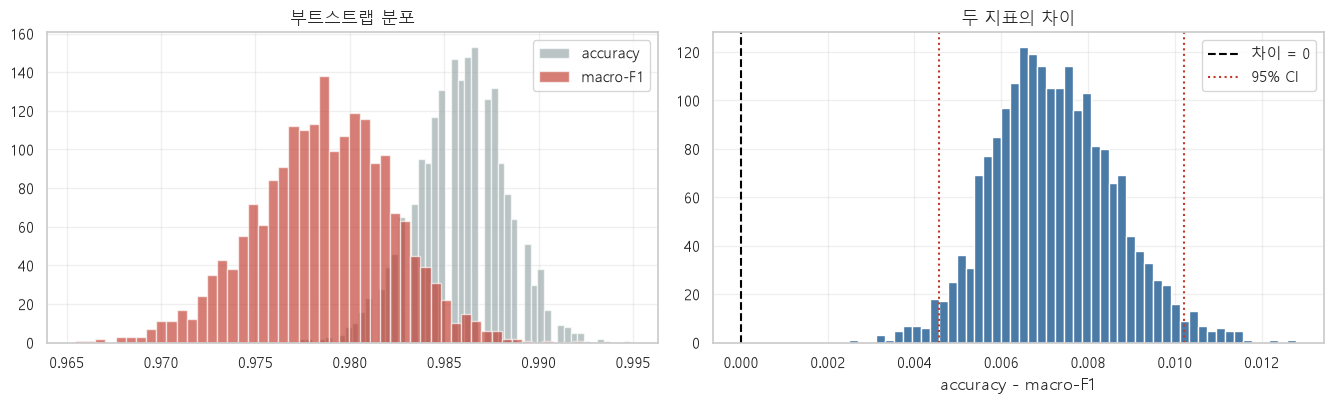

In [16]:
N_BOOT = 2000
n = len(y_test)
accs, f1s, gaps = np.empty(N_BOOT), np.empty(N_BOOT), np.empty(N_BOOT)

for b in range(N_BOOT):
    idx = rng.integers(0, n, n)
    yt, yp = y_test[idx], base_pred[idx]
    accs[b] = accuracy_score(yt, yp)
    f1s[b]  = f1_score(yt, yp, average="macro", zero_division=0)
    gaps[b] = accs[b] - f1s[b]

ci = lambda a: (float(np.percentile(a, 2.5)), float(np.percentile(a, 97.5)))
acc_obs = final["accuracy"]; f1_obs = final["macro_f1"]

print(f"부트스트랩 {N_BOOT}회 (test {n:,}장)\n")
print(f"accuracy  {acc_obs:.4f}  95% CI [{ci(accs)[0]:.4f}, {ci(accs)[1]:.4f}]")
print(f"macro-F1  {f1_obs:.4f}  95% CI [{ci(f1s)[0]:.4f}, {ci(f1s)[1]:.4f}]")
lo, hi = ci(gaps)
print(f"차이      {acc_obs - f1_obs:.4f}  95% CI [{lo:.4f}, {hi:.4f}]")
print()
if lo > 0:
    print(f"신뢰구간이 0을 포함하지 않음 (하한 {lo:.4f} > 0) -> H0 기각")
    print("accuracy가 macro-F1보다 유의하게 큽니다. 소수 클래스 성능이 가려지고 있습니다.")
else:
    print(f"신뢰구간이 0을 포함 -> H0 기각 실패")

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.2))
axes[0].hist(accs, bins=50, alpha=0.65, label="accuracy", color="#95a5a6")
axes[0].hist(f1s, bins=50, alpha=0.65, label="macro-F1", color="#c0392b")
axes[0].set_title("부트스트랩 분포"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(gaps, bins=50, color="#4a7ba7")
axes[1].axvline(0, color="black", ls="--", label="차이 = 0")
axes[1].axvline(lo, color="#c0392b", ls=":", label="95% CI")
axes[1].axvline(hi, color="#c0392b", ls=":")
axes[1].set_xlabel("accuracy - macro-F1")
axes[1].set_title("두 지표의 차이"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig("fig_bootstrap_gap.png", dpi=150); plt.show()

      label  support     f1  ci_low  ci_high  ci_width
    plastic      130 0.9318  0.8987   0.9604    0.0617
white-glass      116 0.9478  0.9188   0.9760    0.0572
      metal      116 0.9707  0.9464   0.9895    0.0431
      trash      105 0.9810  0.9608   1.0000    0.0392
  cardboard      135 0.9811  0.9641   0.9962    0.0321
brown-glass       92 0.9838  0.9643   1.0000    0.0357
    battery      143 0.9860  0.9710   0.9967    0.0258
green-glass       93 0.9891  0.9717   1.0000    0.0283
 biological      149 0.9900  0.9755   1.0000    0.0245
      paper      158 0.9904  0.9789   1.0000    0.0211
      shoes      304 0.9934  0.9866   0.9985    0.0119
    clothes      793 0.9994  0.9975   1.0000    0.0025


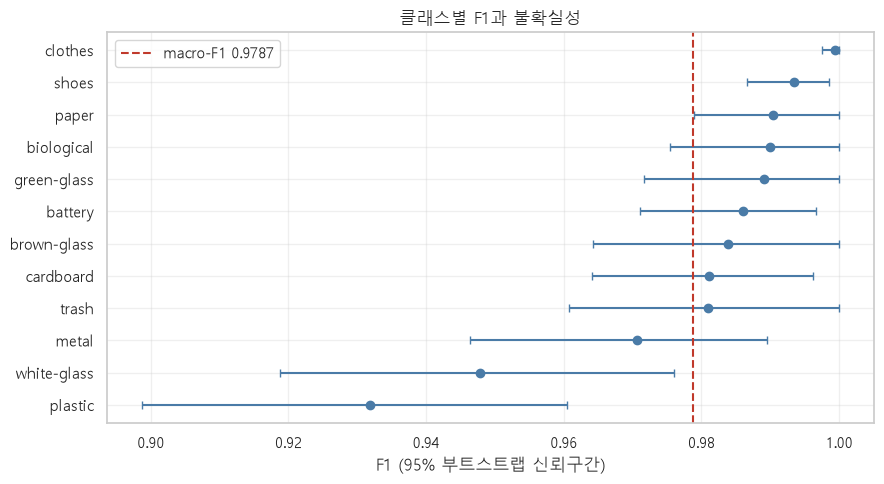

In [17]:
# 클래스별 F1의 신뢰구간 — 어느 클래스가 불안정한가
rows = []
for c_idx, c in enumerate(classes):
    v = np.empty(500)
    for b in range(500):
        idx = rng.integers(0, n, n)
        v[b] = f1_score(y_test[idx], base_pred[idx], labels=[c_idx],
                        average="macro", zero_division=0)
    l, h = ci(v)
    rows.append({"label": c, "support": int((y_test == c_idx).sum()),
                 "f1": round(float(f1_all[c_idx]), 4),
                 "ci_low": round(l, 4), "ci_high": round(h, 4),
                 "ci_width": round(h - l, 4)})

cls_ci = pd.DataFrame(rows).sort_values("f1")
print(cls_ci.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
yy = np.arange(len(cls_ci))
ax.errorbar(cls_ci["f1"], yy,
            xerr=[cls_ci["f1"] - cls_ci["ci_low"], cls_ci["ci_high"] - cls_ci["f1"]],
            fmt="o", color="#4a7ba7", capsize=3)
ax.set_yticks(yy); ax.set_yticklabels(cls_ci["label"])
ax.axvline(f1_obs, ls="--", color="#c0392b", label=f"macro-F1 {f1_obs:.4f}")
ax.set_xlabel("F1 (95% 부트스트랩 신뢰구간)")
ax.set_title("클래스별 F1과 불확실성")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("fig_class_ci.png", dpi=150); plt.show()

### 검정 3 — 임계값 조정이 개선을 만들었는가

**분석**: 3절에서 val로 고른 클래스별 가중치를 test에 적용했다. 그 변화가 우연인지 검정한다.

**가설**
> H0: 기본 argmax와 가중 argmax의 오분류율에 차이가 없다.
> H1: 차이가 있다.

**방법**: 같은 test 셋에 대한 두 예측이므로 대응표본이다. McNemar 검정을 쓴다.
불일치 쌍이 25 미만이면 정규근사가 부정확하므로 이항 정확검정으로 전환한다.

In [18]:
cb = (base_pred == y_test)
ca = (adj_pred == y_test)
a_ = int((cb & ca).sum()); b_ = int((cb & ~ca).sum())
c_ = int((~cb & ca).sum()); d_ = int((~cb & ~ca).sum())

print(f"{'':>14}{'조정 맞음':>12}{'조정 틀림':>12}")
print(f"{'기본 맞음':>14}{a_:>12,}{b_:>12}")
print(f"{'기본 틀림':>14}{c_:>12}{d_:>12}")
print(f"\n불일치 쌍 b + c = {b_ + c_}")

if b_ + c_ == 0:
    print("\n두 예측이 완전히 동일합니다. 검정 자체가 성립하지 않습니다.")
    print("""
[해석] val에서 최적 alpha가 0.00으로 나왔다. 사전확률 보정을 아무리 걸어도
  macro-F1이 개선되지 않는다는 뜻이며, 실제로 test 예측이 한 장도 바뀌지 않았다.
  이 모델은 이미 클래스 간 결정 경계가 충분히 잘 잡혀 있어 사후 조정의 여지가 없다.
  '기법을 적용했더니 좋아졌다'가 아니라 '적용할 여지가 없음을 확인했다'가 결론이다.""")
elif b_ + c_ < 25:
    res = stats.binomtest(b_, b_ + c_, 0.5, alternative="two-sided")
    print("\n[McNemar - 이항 정확검정] (b+c < 25)")
    print(" ", verdict(res.pvalue))
else:
    chi2 = (abs(b_ - c_) - 1) ** 2 / (b_ + c_)
    print("\n[McNemar - 카이제곱, 연속성 보정]")
    print(f"  chi2 = {chi2:.4f}, df = 1")
    print(" ", verdict(1 - stats.chi2.cdf(chi2, df=1)))

                     조정 맞음       조정 틀림
         기본 맞음       2,301           0
         기본 틀림           0          33

불일치 쌍 b + c = 0

두 예측이 완전히 동일합니다. 검정 자체가 성립하지 않습니다.

[해석] val에서 최적 alpha가 0.00으로 나왔다. 사전확률 보정을 아무리 걸어도
  macro-F1이 개선되지 않는다는 뜻이며, 실제로 test 예측이 한 장도 바뀌지 않았다.
  이 모델은 이미 클래스 간 결정 경계가 충분히 잘 잡혀 있어 사후 조정의 여지가 없다.
  '기법을 적용했더니 좋아졌다'가 아니라 '적용할 여지가 없음을 확인했다'가 결론이다.


### 검정 4 — 확신도 보류가 자동 처리 정확도를 높였는가

**분석**: 3절 방식 ③에서 tau 이상만 자동 처리했다. 자동 처리한 부분의 정확도가 전체 정확도보다
유의하게 높은지 확인한다. 높지 않다면 보류 규칙이 무의미하다.

**가설**
> H0: 자동 처리 구간의 정확도와 전체 정확도가 같다.
> H1: 자동 처리 구간의 정확도가 더 높다.

**방법**: 부트스트랩 신뢰구간. 두 구간이 겹치지 않으면 차이가 유의하다고 본다.

In [19]:
conf_t = test_probs.max(axis=1)
mask = conf_t >= TAU

diff = np.empty(N_BOOT)
for b in range(N_BOOT):
    idx = rng.integers(0, n, n)
    m = mask[idx]
    if m.sum() < 10:
        diff[b] = np.nan
        continue
    diff[b] = (accuracy_score(y_test[idx][m], base_pred[idx][m])
               - accuracy_score(y_test[idx], base_pred[idx]))
diff = diff[~np.isnan(diff)]
lo_d, hi_d = ci(diff)

auto_acc = accuracy_score(y_test[mask], base_pred[mask])
print(f"tau = {TAU:.2f}")
print(f"  전체 정확도       {acc_obs:.4f}")
print(f"  자동 처리 정확도  {auto_acc:.4f}  (커버리지 {mask.mean():.4f}, 보류 {int((~mask).sum())}장)")
print(f"  차이              {auto_acc - acc_obs:.4f}  95% CI [{lo_d:.4f}, {hi_d:.4f}]")
print()
if lo_d > 0:
    print("신뢰구간이 0을 포함하지 않음 -> H0 기각")
    print("확신도로 걸러낸 구간의 정확도가 유의하게 높습니다. 보류 규칙이 작동합니다.")
else:
    print("신뢰구간이 0을 포함 -> H0 기각 실패")

tau = 0.53
  전체 정확도       0.9859
  자동 처리 정확도  0.9884  (커버리지 0.9966, 보류 8장)
  차이              0.0025  95% CI [0.0008, 0.0047]

신뢰구간이 0을 포함하지 않음 -> H0 기각
확신도로 걸러낸 구간의 정확도가 유의하게 높습니다. 보류 규칙이 작동합니다.


## 5. 종합

In [20]:
summary = pd.DataFrame([
    {"번호": 1, "주장": "유리 3종의 색상 분포가 다르다",
     "검정": "순열검정 + Kruskal-Wallis + Mann-Whitney(Bonferroni)",
     "영향": "증강에서 hue=0.0 채택"},
    {"번호": 2, "주장": "accuracy가 소수 클래스 실패를 가린다",
     "검정": "부트스트랩 95% CI", "영향": "주 지표로 macro-F1 채택"},
    {"번호": 3, "주장": "클래스별 임계값 조정이 개선을 만든다",
     "검정": "McNemar", "영향": "사후 조정 불채택"},
    {"번호": 4, "주장": "확신도 보류가 자동 처리 정확도를 높인다",
     "검정": "부트스트랩 95% CI", "영향": f"운영 임계값 tau = {TAU:.2f}"},
])
print(summary.to_string(index=False))

result = {
    "final_model": "EfficientNetV2-S (unfreeze, img 224, lr 1e-4)",
    "n_images": int(len(split)),
    "split": {k: int(v) for k, v in split["split"].value_counts().items()},
    "majority_baseline": {"accuracy": round(float(mb.loc[1, "accuracy"]), 4),
                          "macro_f1": round(float(mb.loc[1, "macro_f1"]), 4)},
    "test": {k: round(float(v), 4) for k, v in final.items()},
    "bootstrap_gap_ci": [round(lo, 4), round(hi, 4)],
    "threshold": {"target_class": TARGET_CLASS,
                  "alpha_best": best_a, "alpha_changed": int(n_changed),
                  "tau": TAU,
                  "tau_test_coverage": round(float(cov_test["coverage"]), 4),
                  "tau_test_auto_accuracy": round(float(cov_test["auto_accuracy"]), 4)},
    "selected_on": "validation only",
}
with open("team_analysis_summary.json", "w", encoding="utf-8") as f:
    json.dump(result, f, ensure_ascii=False, indent=2)
print()
print(json.dumps(result, ensure_ascii=False, indent=2))

 번호                       주장                                               검정                영향
  1        유리 3종의 색상 분포가 다르다 순열검정 + Kruskal-Wallis + Mann-Whitney(Bonferroni)   증강에서 hue=0.0 채택
  2 accuracy가 소수 클래스 실패를 가린다                                     부트스트랩 95% CI 주 지표로 macro-F1 채택
  3     클래스별 임계값 조정이 개선을 만든다                                          McNemar         사후 조정 불채택
  4   확신도 보류가 자동 처리 정확도를 높인다                                     부트스트랩 95% CI 운영 임계값 tau = 0.53

{
  "final_model": "EfficientNetV2-S (unfreeze, img 224, lr 1e-4)",
  "n_images": 15484,
  "split": {
    "train": 10832,
    "test": 2334,
    "val": 2318
  },
  "majority_baseline": {
    "accuracy": 0.3398,
    "macro_f1": 0.0423
  },
  "test": {
    "accuracy": 0.9859,
    "balanced_acc": 0.979,
    "macro_f1": 0.9787,
    "weighted_f1": 0.9859,
    "macro_recall": 0.979,
    "macro_prec": 0.9787,
    "macro_auc": 0.9998
  },
  "bootstrap_gap_ci": [
    0.0046,
    0.0102
  ],
  "threshold": {
    "target_clas

## 정리와 한계

**세 채점 기준의 대응**

| 기준 | 근거 |
|---|---|
| 평가지표 선정 | 다수 클래스 기준선에서 정확도와 macro-F1이 8배 차이. 부트스트랩으로 격차의 유의성 확인 |
| 가설검정 | 순열검정, Kruskal-Wallis + Mann-Whitney, 부트스트랩 CI 2회, McNemar |
| 임계값 변화 | OvR 스윕, 클래스별 가중 argmax, 확신도 보류 — 모두 val에서 선택하고 test에 1회 적용 |

**한계**

- **탐지 threshold는 임의값이다.** 근접중복 판정의 Hamming 5, 픽셀차 0.05는 시행착오로 정한 값이다.
- **라벨 검수가 클래스마다 고르지 않다.** 확신도 기반 진단은 모델이 확신하며 틀린 것만 후보로
  올리므로, 모델이 애초에 잘 못 배우는 유형의 오류는 놓친다.
- **단일 시드 단일 학습이다.** 하이퍼파라미터 비교에서 관측된 0.005 안팎의 차이는 run-to-run
  변동 폭 안에 있을 가능성이 높다. 여러 시드로 반복해야 확정할 수 있다.
- **누수 방지의 효과를 정량화하지 않았다.** 단순 분할 시 13그룹 26장이 갈라진다는 것은 확인했으나,
  그것이 성능을 얼마나 부풀리는지는 측정하지 않았다.
- **증강 효과가 조건에 따라 뒤집힌다.** 팀 내 다른 실험에서 얕은 CNN은 증강이 오히려 해로웠고
  (macro-F1 0.829 -> 0.789), 전이학습에서는 차이가 유의하지 않았다(순열검정 p = 0.42).
  최종 모델은 증강을 채택했으나, 증강이 항상 이득이라는 일반화는 성립하지 않는다.